# HW 4 — Applied Statistics for ML on NOAA NDBC Buoy 44013

This homework applies **Module 4 (A–E)** using the **NOAA NDBC buoy dataset** (station **44013**).

You will practice:
- **A — Probability fundamentals:** events, marginals, conditionals, reversals  
- **B — Common distributions:** binomial / Poisson / normal, and where they fail  
- **C — Estimation & inference:** confidence intervals, hypothesis tests, ANOVA-style comparisons  
- **D — Resampling & simulation:** bootstrap, permutation tests, Monte Carlo  
- **E — Responsible interpretation:** practical vs statistical significance, pitfalls, limitations

> **Theme:** Operational ocean conditions are noisy, seasonal, and autocorrelated.  
> Your job is to quantify uncertainty *without pretending the world is i.i.d.*

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional (nice-to-have)
try:
    from scipy import stats
except Exception:
    stats = None

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

rng = np.random.default_rng() 

## 1) Load the curated buoy parquet from HW2 (station 44013)

If this fails, re-run Homework 2 (NOAA) to regenerate the parquet.

In [2]:
# Paths from Module 2 NOAA homework



Looking for: /home/jupyter-kerblesl@isu.edu/work/homework_2_noaa/data/warehouse/ndbc_curated_44013.parquet
Exists? True
Loaded shape: (6470, 17)


,station_id,time_utc,obs_day,obs_hour,dayofweek,is_weekend,wind_high,temp_gap_c,WSPD,GST,WVHT,DPD,APD,PRES,ATMP,WTMP,WDIR
0,44013,2026-01-25 05:40:00+00:00,2026-01-25,5,6,1,0,-15.3,9.0,12.0,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0
1,44013,2026-01-25 05:30:00+00:00,2026-01-25,5,6,1,0,-15.3,10.0,12.0,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0
2,44013,2026-01-25 05:20:00+00:00,2026-01-25,5,6,1,0,-15.1,9.0,12.0,1.2,5.0,3.8,1037.2,-10.2,4.9,330.0
3,44013,2026-01-25 05:10:00+00:00,2026-01-25,5,6,1,0,-15.0,9.0,12.0,NaN,NaN,NaN,1037.4,-10.1,4.9,330.0
4,44013,2026-01-25 05:00:00+00:00,2026-01-25,5,6,1,0,-15.0,9.0,12.0,NaN,NaN,NaN,1037.4,-10.2,4.8,320.0


### Sanity checks

Expected columns:
`station_id, time_utc, obs_day, obs_hour, dayofweek, is_weekend, wind_high, temp_gap_c, WSPD, GST, WVHT, DPD, APD, PRES, ATMP, WTMP, WDIR`

Create a clean working frame `d`:
- ensure datetime
- coerce numeric columns
- drop missing timestamps

station_id                 object
time_utc      datetime64[ns, UTC]
obs_day                    object
obs_hour                    int32
dayofweek                   int32
is_weekend                  int64
wind_high                   int64
temp_gap_c                float64
WSPD                      float64
GST                       float64
WVHT                      float64
DPD                       float64
APD                       float64
PRES                      float64
ATMP                      float64
WTMP                      float64
WDIR                      float64
dtype: object

Working shape: (6470, 17)
Station IDs: station_id
44013    6470
Name: count, dtype: int64


## 2) Helpers

You can reuse the same helper ideas from Module 4:
- probability and conditional probability
- bootstrap sampling distributions + percentile CI
- permutation tests for difference in a statistic

## 3) A — Probability fundamentals (events, marginals, conditionals, reversals)

Define a few *operational* events from buoy observations:

- `high_waves`: significant wave height `WVHT >= 3.0` meters  
- `windy`: sustained wind speed `WSPD >= 10` m/s  
- `gusty`: gust `GST >= 15` m/s  
- `weekend`: `is_weekend == 1`  
- `temp_gap`: large air–water gap `|temp_gap_c| >= 3°C` (proxy for strong thermal contrast)

These thresholds are not sacred. The point is to define events explicitly.

n rows for events: 2577
P(high_waves): 0.002716336825766395
P(windy): 0.30151338766006985
P(gusty): 0.18199456732634847
P(weekend): 0.286767559177338
P(temp_gap): 0.7004268529297633


### Conditionals 

Compare:
- $P(\mathrm{high\_waves}\mid \mathrm{windy})$ vs $P(\mathrm{windy}\mid \mathrm{high\_waves})$
- $P(\mathrm{high\_waves}\mid \mathrm{weekend})$ vs $P(\mathrm{high\_waves}\mid \mathrm{weekday})$

P(high_waves | windy): 0.002574002574002574
P(windy | high_waves): 0.2857142857142857

P(high_waves | weekend): 0.0
P(high_waves | weekday): 0.003808487486398259


### Bayes-style reversal with empirical frequencies

Using $A=\mathrm{high\_waves}$ and $B=\mathrm{windy}$:

$$
P(A\mid B) = \frac{P(B\mid A)P(A)}{P(B)}
$$

Empirical P(high_waves | windy): 0.002574002574002574
Bayes from counts: 0.002574002574002574
Abs diff: 0.0


## 4) B — Common distributions + failure modes

### 4.1 Binomial: high waves among windy hours
Treat each *windy hour* as a trial; “success” = high waves.
Compare analytic (binomial) uncertainty vs bootstrap uncertainty.

n windy hours: 777
k high_waves among windy: 2
p_hat: 0.002574002574002574

Analytic (binomial) uncertainty:
  SE_binom(p_hat): 0.0018177507013594917
  Wald 95% CI: (-0.0009887888006620297, 0.0061367939486671776)

Bootstrap uncertainty (empirical):
  SE_boot(p_hat): 0.001839924549209491
  Bootstrap 95% CI: (0.0, 0.006435006435006435)


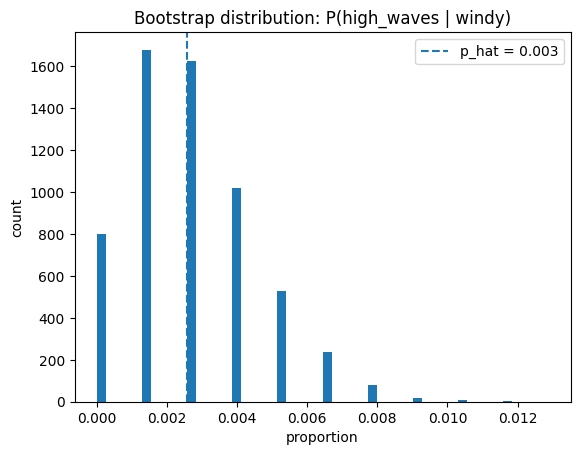


Your comments here:


### 4.2 Poisson: count of high-wave hours per day

Let $C_d$ be the number of hours on day $d$ with `WVHT >= 3.0`.
A Poisson model would imply $\mathrm{Var}(C_d) \approx \mathrm{Mean}(C_d)$.

Compare the empirical daily-count distribution to a Poisson($\hat\lambda$) baseline and check overdispersion.

Days: 46
lambda_hat (mean high-wave hours/day): 0.15217391304347827
Var(count): 0.6207729468599033
Var/Mean: 4.079365079365078
Bootstrap 95% CI for lambda: (0.0, 0.41304347826086957)


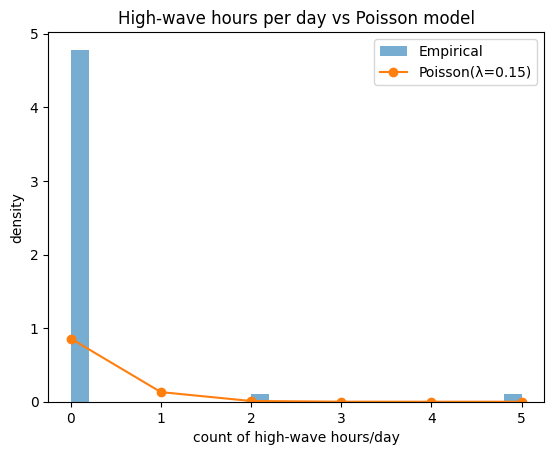


Interpretation:
- Var >> Mean suggests clustering (storms) or non-constant rate → Poisson too simple.
- Poisson can be a baseline, not a literal truth.


### 4.3 Normal: water temperature (WTMP) as a cautionary example

Visualize WTMP and compare mean vs median and tail quantiles.

n WTMP: 6392
mean: 6.446761576971213
median: 6.1
p05: 5.1 p95: 8.2


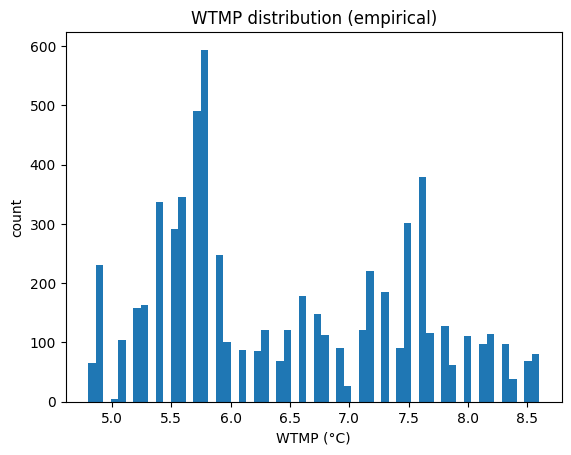


Notes:
- If the histogram shows multiple modes, normal is a poor description.
- Seasonality is a common reason for 'not normal'.


## 5) C — Estimation and inference

### 5.1 Confidence interval: mean WVHT on weekends vs weekdays (bootstrap)

n weekend: 744 n weekday: 1857
mean WVHT weekend: 0.9240591397849462
mean WVHT weekday: 1.0078082929456111
mean diff (wk - wd): -0.08374915316066489

Bootstrap 95% CI mean WVHT weekend: (0.8942204301075268, 0.9540322580645161)
Bootstrap 95% CI mean WVHT weekday: (0.9826063543349489, 1.0322563274098009)


### 5.2 Hypothesis test: permutation test for weekend vs weekday median WVHT

Observed median diff (weekend - weekday): 0.0
Permutation p ≈ 1.0


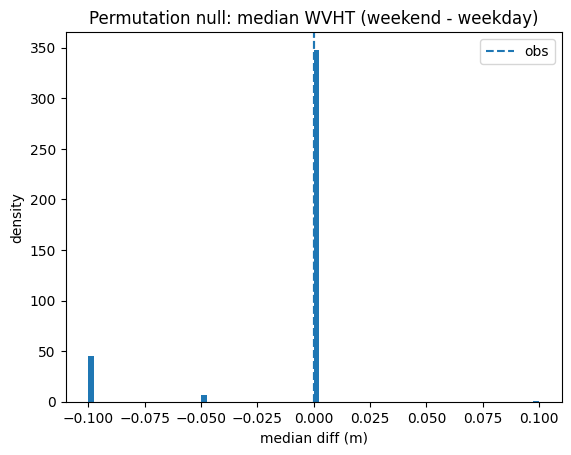


Interpretation:
- Small p means the label structure is unlikely under exchangeability.
- It does NOT mean the effect is large or important.


### 5.3 ANOVA-style comparison across hour-of-day bins

ANOVA asks whether all group means are equal (not which ones differ).

Groups used: ['afternoon', 'evening', 'morning', 'night']
n per group: [652, 669, 650, 630]
mean WVHT per group: {'afternoon': 0.964877300613497, 'evening': 0.9693572496263079, 'morning': 1.0104615384615383, 'night': 0.9914285714285713}
ANOVA: F = 1.0983972818660894 p = 0.3485153006412522


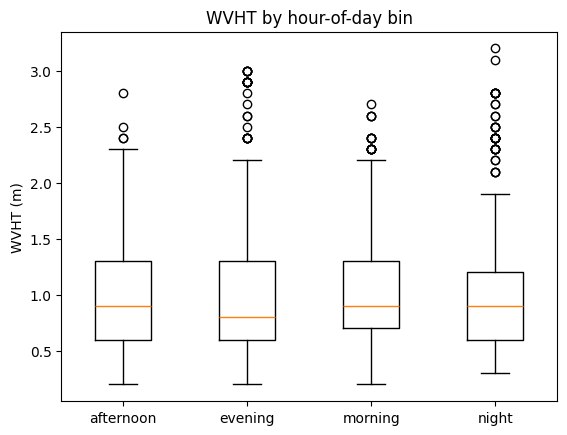


Notes:
- 
- 


## 6) D — Resampling & simulation

### 6.1 Bootstrap: tail risk (p95 WVHT)

Observed p95 WVHT: 2.0
Bootstrap 95% CI p95 WVHT: (1.9, 2.1)


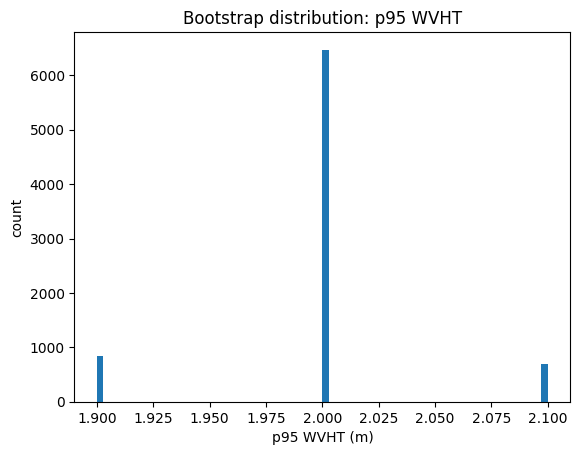

### 6.2 Monte Carlo: risk of at least one high-wave hour tomorrow

Empirical MC P(day has ≥1 high-wave hour): 0.04195

Assumptions:
- Treats historical days as representative of 'tomorrow'.
- Ignores seasonality unless you condition the sampling (extension idea).


## 7) E — Interpreting results responsibly

Assume stakeholders say:
> A change of **0.25 m** in median WVHT is the smallest difference worth reacting to.

Estimate the weekend–weekday median difference + bootstrap CI and compare to that threshold.

Practical threshold (m): 0.25
Observed median diff (wk - wd): 0.0
Bootstrap 95% CI: (-0.09999999999999998, 0.09999999999999998)
CI entirely above threshold? False
CI overlaps 0? True


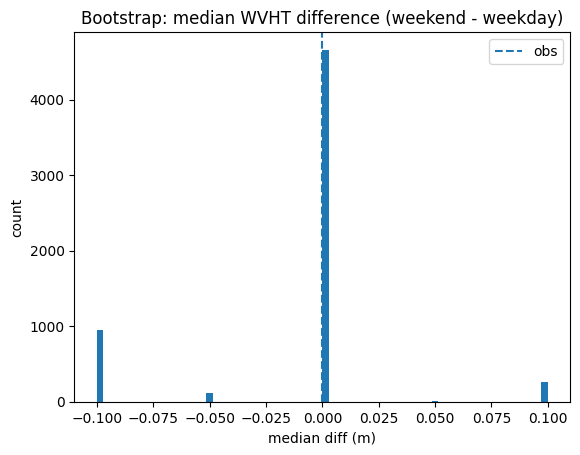


Reminder:
- A tiny p-value does not imply an operationally meaningful difference.
- Autocorrelation and seasonality can make naive inference overconfident.


## 8) Solutions narrative (example)

Write **8 bullets** (one per line), matching the structure used in Module 4.F.

In [17]:
# Your 8 bullets, below is just an example


1) Slice: Used buoy 44013 curated parquet; dropped missing WVHT/WSPD/GST/temp_gap for event definitions; treated rows as hourly observations (not i.i.d).
2) Probability: Defined events high_waves(WVHT≥3m) and windy(WSPD≥10). Estimated P(high_waves)=0.003, and P(high_waves|windy)=0.003 differs from P(windy|high_waves)=0.286 due to base rates.
3) Distributions: Modeled daily high-wave-hour counts with Poisson(λ̂≈0.15); Var/Mean≈4.08 suggested clustering (storms) so Poisson is a baseline, not literal truth.
4) Estimation: Weekend vs weekday mean WVHT differed by ≈-0.084 m; uncertainty quantified via bootstrap CIs rather than assuming normality.
5) Inference: Permutation test on median WVHT gave p≈1.0000; even if 'significant', effect size must be judged in meters against operational needs.
6) Resampling: Bootstrapped p95 WVHT: obs=2.00 m with CI=(1.9, 2.1), emphasizing tail risk rather than averages.
7) Simulation: Empirical Monte Carlo estimated P(day has ≥1 high-wave hour)≈0.047 by resa